<a href="https://colab.research.google.com/github/filiz07/cyberbullying-recommendation-exposure/blob/main/Dissertation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Cell 0 — Mount Google Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Cell 1 — Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import string

import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

pd.set_option("display.max_columns", None)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


# **Cell 2 — Load Datasets**

In [ ]:
DATA_DIR = "/content/drive/MyDrive/"

# Data 1: COVID tweets (3 time windows combined)
covid_files = [
    DATA_DIR + "Covid-19 Twitter Dataset (Apr-Jun 2020).csv",
    DATA_DIR + "Covid-19 Twitter Dataset (Aug-Sep 2020).csv",
    DATA_DIR + "Covid-19 Twitter Dataset (Apr-Jun 2021).csv",
]
df1 = pd.concat([pd.read_csv(f, low_memory=False) for f in covid_files], ignore_index=True)

# Data 2: Cyberbullying tweets (recommendation pool)
df2 = pd.read_csv(DATA_DIR + "cyberbullying_tweets.csv")

print("Data 1 shape:", df1.shape)
print("Data 2 shape:", df2.shape)
print("\nData 2 class distribution:")
print(df2["cyberbullying_type"].value_counts())

Data 1 shape: (411887, 17)
Data 2 shape: (47692, 2)

Data 2 class distribution:
cyberbullying_type
religion               7998
age                    7992
gender                 7973
ethnicity              7961
not_cyberbullying      7945
other_cyberbullying    7823
Name: count, dtype: int64


# **Cell 2b — Understand Dataset**

Data 1 - First 5 rows:


,id,created_at,source,original_text,lang,favorite_count,retweet_count,original_author,hashtags,user_mentions,place,clean_tweet,compound,neg,neu,pos,sentiment
0,1.250000e+18,2020-04-19,"<a href=""http://twitter.com/download/android"" ...",RT @GlblCtzn: .@priyankachopra is calling on l...,en,0.0,31.0,RJIshak,NaN,"GlblCtzn, priyankachopra",Jakarta Capital Region,call leader help protect refuge covid19 provid...,0.8176,0.0,0.452,0.548,pos
1,1.250000e+18,2020-04-19,"<a href=""http://twitter.com/download/android"" ...",RT @OGSG_Official: OGUN STATE SUPPORT FOR CBN-...,en,0.0,61.0,makinwaoluwole,NaN,OGSG_Official,Nigeria,ogun state support cbn nirsal covid19 target c...,0.6486,0.0,0.602,0.398,pos
2,1.250000e+18,2020-04-19,"<a href=""http://twitter.com/download/iphone"" r...",RT @AdvoBarryRoux: These 5 police officials ba...,en,0.0,1.0,TembeAmu,NaN,AdvoBarryRoux,NaN,polic offici base namahadi polic station busi ...,0.2732,0.0,0.851,0.149,pos
3,1.250000e+18,2020-04-19,"<a href=""http://twitter.com/download/iphone"" r...",RT @MobilePunch: COVID-19: Oyo discharges two ...,en,0.0,0.0,ilyasrabiu,NaN,MobilePunch,"Lagos, Nigeria",covid19 oyo discharg two patient,0.0000,0.0,1.000,0.000,neu
4,1.250000e+18,2020-04-19,"<a href=""http://twitter.com/download/android"" ...",My Condolences to the Family of those who did ...,en,0.0,13869.0,bucketeconomist,Covid_19,NaN,NaN,condol famili surviv,0.0000,0.0,1.000,0.000,neu



Data 2 - First 5 rows:


,tweet_text,cyberbullying_type
0,"In other words #katandandre, your food was cra...",not_cyberbullying
1,Why is #aussietv so white? #MKR #theblock #ImA...,not_cyberbullying
2,@XochitlSuckkks a classy whore? Or more red ve...,not_cyberbullying
3,"@Jason_Gio meh. :P thanks for the heads up, b...",not_cyberbullying
4,@RudhoeEnglish This is an ISIS account pretend...,not_cyberbullying



Data 1 shape (rows, columns): (411887, 17)
Data 2 shape (rows, columns): (47692, 2)

Data 1 columns:
['id', 'created_at', 'source', 'original_text', 'lang', 'favorite_count', 'retweet_count', 'original_author', 'hashtags', 'user_mentions', 'place', 'clean_tweet', 'compound', 'neg', 'neu', 'pos', 'sentiment']

Data 2 columns:
['tweet_text', 'cyberbullying_type']

Data 1 info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 411887 entries, 0 to 411886
Data columns (total 17 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   id               411883 non-null  float64
 1   created_at       411885 non-null  object 
 2   source           411587 non-null  object 
 3   original_text    411885 non-null  object 
 4   lang             411884 non-null  object 
 5   favorite_count   411884 non-null  float64
 6   retweet_count    411884 non-null  float64
 7   original_author  411884 non-null  object 
 8   hashtags         97775 non-null   o

,id,favorite_count,retweet_count,compound,neg,neu,pos
count,4.118830e+05,411884.000000,411884.000000,411887.000000,411887.000000,411887.000000,411887.000000
mean,1.324197e+18,0.216726,1585.174163,0.008415,0.090920,0.807021,0.102052
std,5.902218e+16,6.332250,9423.896052,0.370853,0.152717,0.200474,0.157080
min,1.250000e+18,0.000000,0.000000,-0.992500,0.000000,0.000000,0.000000
25%,1.260000e+18,0.000000,1.000000,-0.102700,0.000000,0.667000,0.000000
50%,1.310000e+18,0.000000,15.000000,0.000000,0.000000,0.819000,0.000000
75%,1.395011e+18,0.000000,243.000000,0.226300,0.180000,1.000000,0.200000
max,1.409140e+18,2923.000000,416923.000000,0.980500,1.000000,1.000000,1.000000



Data 2 summary:


,tweet_text,cyberbullying_type
count,47692,47692
unique,46017,6
top,Going to see @TheQuinnspiracy's movie I AM SO ...,religion
freq,2,7998



Missing values in Data 1:
id                      4
created_at              2
source                300
original_text           2
lang                    3
favorite_count          3
retweet_count           3
original_author         3
hashtags           314112
user_mentions      116680
place              118112
clean_tweet          1972
compound                0
neg                     0
neu                     0
pos                     0
sentiment               0
dtype: int64

Missing values in Data 2:
tweet_text            0
cyberbullying_type    0
dtype: int64


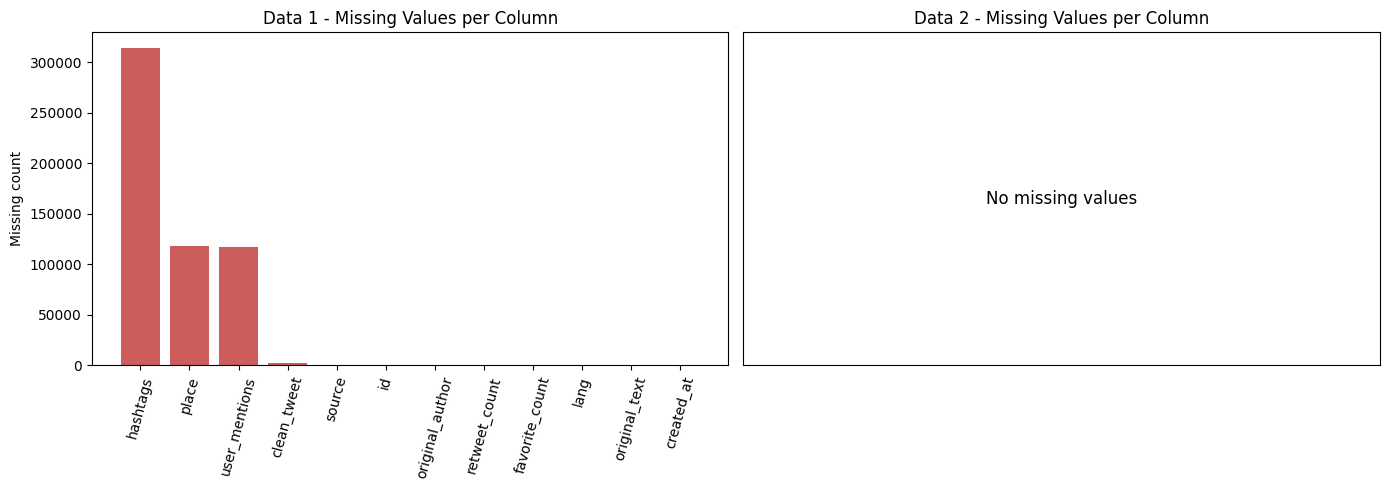

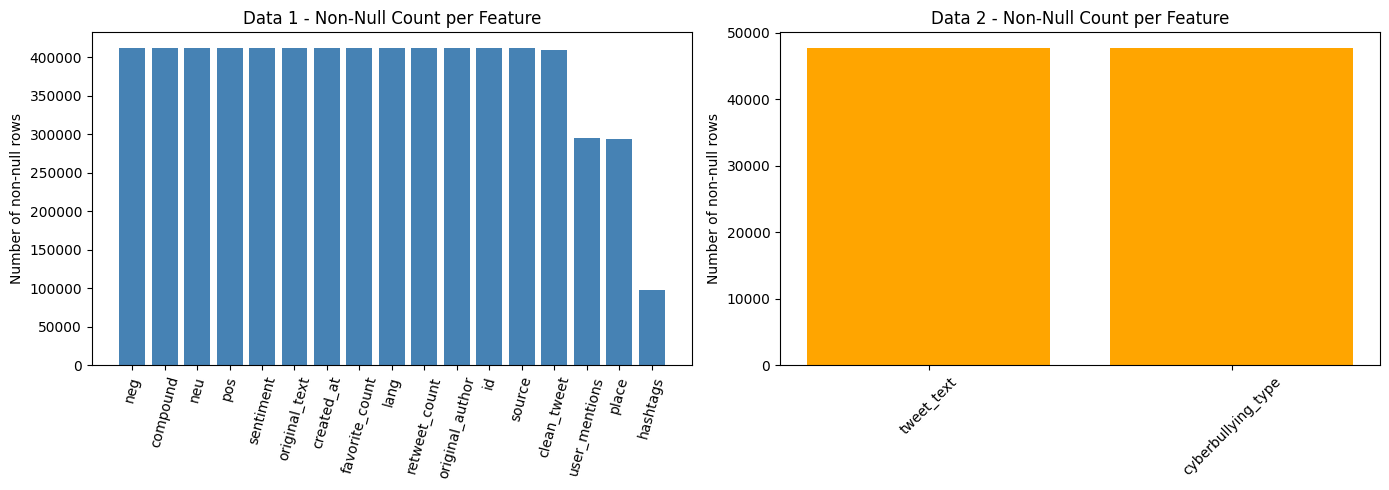

In [ ]:
from IPython.display import display

# --- Data 1: first 5 rows ---
print("Data 1 - First 5 rows:")
display(df1.head())

# --- Data 2: first 5 rows ---
print("\nData 2 - First 5 rows:")
display(df2.head())

# --- Shape ---
print("\nData 1 shape (rows, columns):", df1.shape)
print("Data 2 shape (rows, columns):", df2.shape)

# --- Column names ---
print("\nData 1 columns:")
print(df1.columns.tolist())
print("\nData 2 columns:")
print(df2.columns.tolist())

# --- Data types ---
print("\nData 1 info:")
print(df1.info())
print("\nData 2 info:")
print(df2.info())

# --- Statistical summary ---
print("\nData 1 numeric summary:")
display(df1.describe())
print("\nData 2 summary:")
display(df2.describe(include="all"))

# --- Missing values ---
print("\nMissing values in Data 1:")
print(df1.isnull().sum())
print("\nMissing values in Data 2:")
print(df2.isnull().sum())

# --- Missing values bar chart ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

missing1 = df1.isnull().sum()
missing1 = missing1[missing1 > 0].sort_values(ascending=False)
axes[0].bar(missing1.index.astype(str), missing1.values, color="indianred")
axes[0].set_title("Data 1 - Missing Values per Column")
axes[0].set_ylabel("Missing count")
axes[0].tick_params(axis='x', rotation=75)

missing2 = df2.isnull().sum()
missing2 = missing2[missing2 > 0]
if len(missing2) == 0:
    axes[1].text(0.5, 0.5, "No missing values", ha="center",
                 va="center", fontsize=12)
    axes[1].set_xticks([])
    axes[1].set_yticks([])
else:
    axes[1].bar(missing2.index.astype(str), missing2.values, color="indianred")
axes[1].set_title("Data 2 - Missing Values per Column")

plt.tight_layout()
plt.show()



# --- Non-null count per feature bar chart ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts1 = df1.count().sort_values(ascending=False)
axes[0].bar(counts1.index.astype(str), counts1.values, color="steelblue")
axes[0].set_title(f"Data 1 - Non-Null Count per Feature")
axes[0].set_ylabel("Number of non-null rows")
axes[0].tick_params(axis='x', rotation=75)

counts2 = df2.count().sort_values(ascending=False)
axes[1].bar(counts2.index.astype(str), counts2.values, color="orange")
axes[1].set_title(f"Data 2 - Non-Null Count per Feature")
axes[1].set_ylabel("Number of non-null rows")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# **Cell 2c — Dataset Visualisation (EDA)**

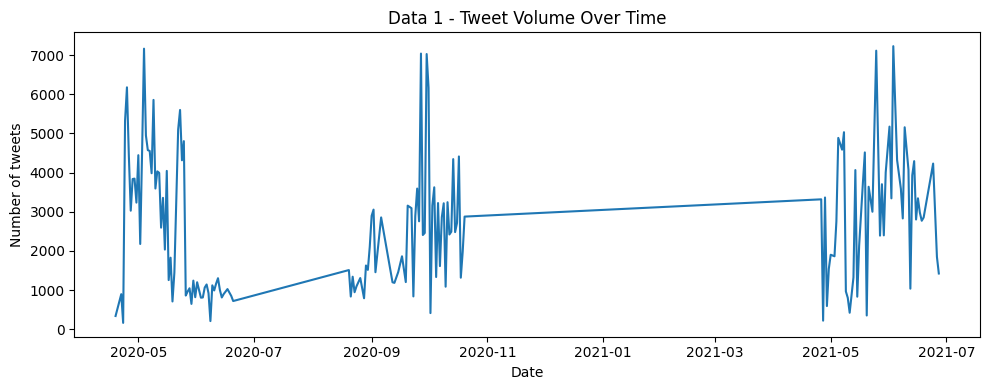

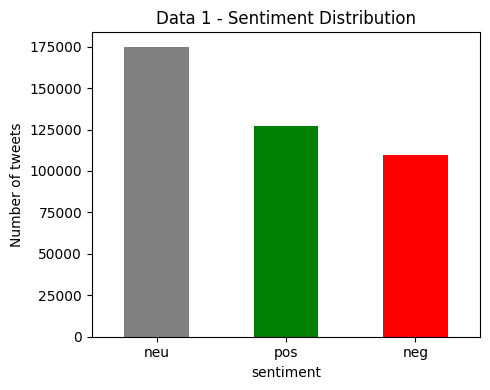

sentiment
neu    174898
pos    127360
neg    109629
Name: count, dtype: int64


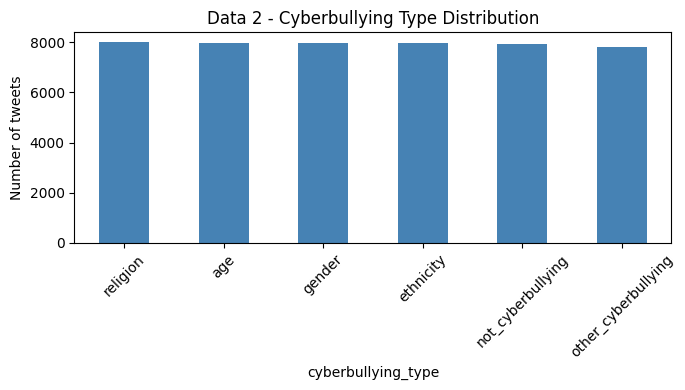

cyberbullying_type
religion               7998
age                    7992
gender                 7973
ethnicity              7961
not_cyberbullying      7945
other_cyberbullying    7823
Name: count, dtype: int64


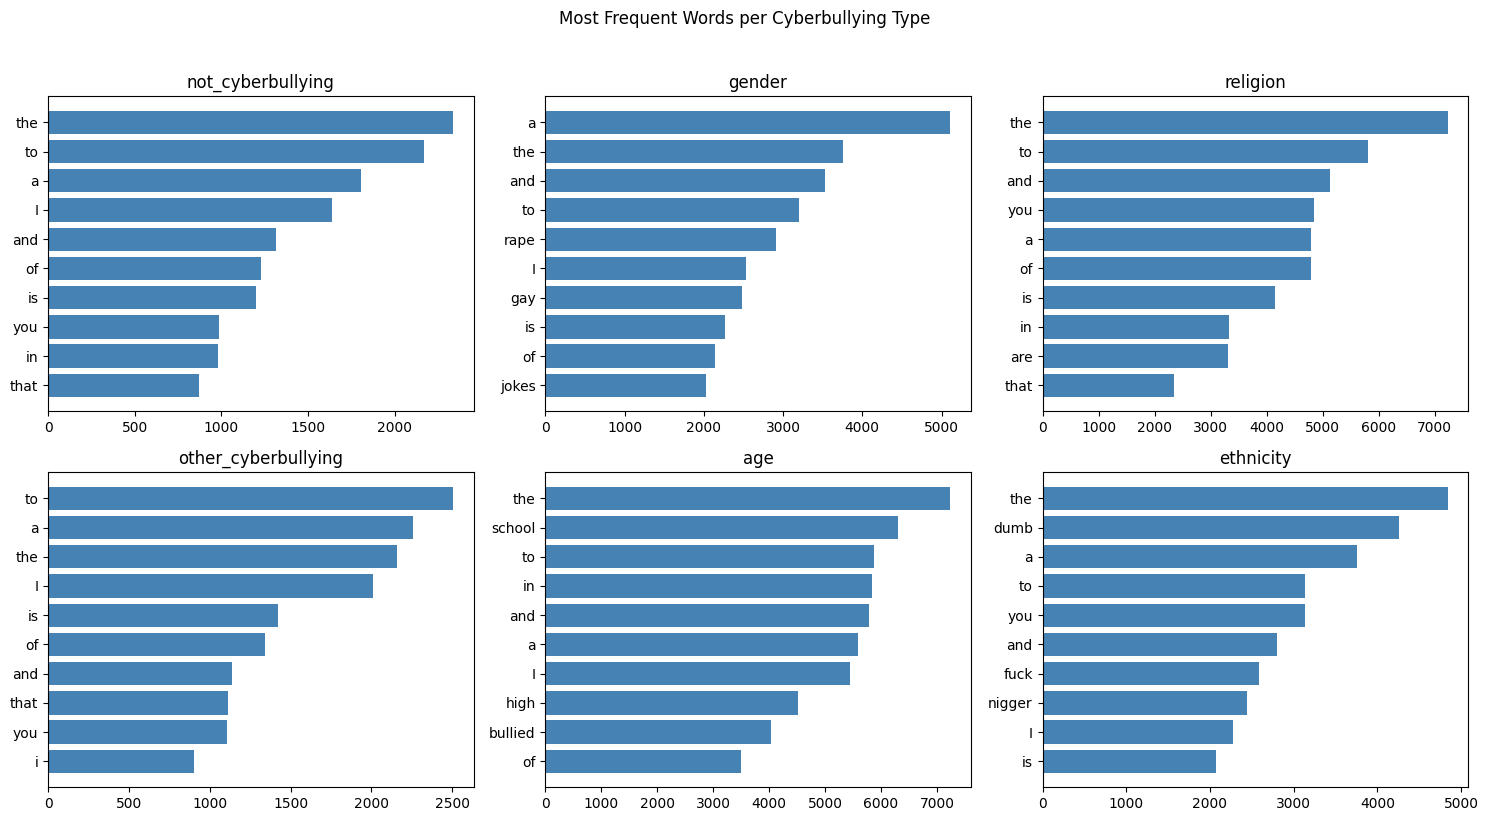

In [ ]:
import re
from collections import Counter

# --- Data 1: Tweet volume over time ---
df1["created_at"] = pd.to_datetime(df1["created_at"], errors="coerce")
tweets_per_day = df1.groupby(df1["created_at"].dt.date).size()

plt.figure(figsize=(10, 4))
tweets_per_day.plot()
plt.title("Data 1 - Tweet Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Number of tweets")
plt.tight_layout()
plt.show()

# --- Data 1: Sentiment distribution ---
sentiment_counts = df1["sentiment"].value_counts()
plt.figure(figsize=(5, 4))
sentiment_counts.plot(kind="bar", color=["gray", "green", "red"])
plt.title("Data 1 - Sentiment Distribution")
plt.ylabel("Number of tweets")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print(sentiment_counts)

# --- Data 2: Class distribution ---
class_counts = df2["cyberbullying_type"].value_counts()
plt.figure(figsize=(7, 4))
class_counts.plot(kind="bar", color="steelblue")
plt.title("Data 2 - Cyberbullying Type Distribution")
plt.ylabel("Number of tweets")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print(class_counts)

# --- Data 2: Most frequent words per class ---
# (uses clean_text from Cell 3 — run Cell 3 first if not done)
def top_words(text_series, n=10):
    words = " ".join(text_series.astype(str)).split()
    return Counter(words).most_common(n)

labels = df2["cyberbullying_type"].unique()
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, label in zip(axes, labels):
    if "clean_text" in df2.columns:
        subset = df2[df2["cyberbullying_type"] == label]["clean_text"]
    else:
        subset = df2[df2["cyberbullying_type"] == label]["tweet_text"]
    word_freq = top_words(subset, n=10)
    if word_freq:
        words, counts = zip(*word_freq)
        ax.barh(words, counts, color="steelblue")
        ax.invert_yaxis()
    ax.set_title(label)

plt.suptitle("Most Frequent Words per Cyberbullying Type", y=1.02)
plt.tight_layout()
plt.show()

# **Cell 3 — Preprocess Data 2 (same NLP pipeline as orginal paper)**

In [ ]:
# We apply the same NLP preprocessing pipeline used in the reference paper:
# lowercase, remove URLs, mentions, emojis, punctuation, numbers, stopwords, stemming
# This makes Data 2 comparable to Data 1's already-cleaned tweet text

stop_words = set(stopwords.words("english"))
stemmer = PorterStemmer()

def preprocess_tweet(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)      # remove URLs
    text = re.sub(r"@\w+", "", text)                  # remove mentions
    text = re.sub(r"[^\x00-\x7f]", "", text)          # remove emojis
    text = re.sub(r"\d+", "", text)                    # remove numbers
    text = text.translate(str.maketrans("", "", string.punctuation))  # remove punctuation
    words = text.split()
    words = [w for w in words if w not in stop_words]  # remove stopwords
    words = [stemmer.stem(w) for w in words]            # stemming
    return " ".join(words).strip()

df2_clean = df2.dropna(subset=["tweet_text", "cyberbullying_type"]).copy()
df2_clean["clean_text"] = df2_clean["tweet_text"].apply(preprocess_tweet)

print("Data 2 after preprocessing:")
print(df2_clean[["tweet_text", "clean_text"]].head(3))

Data 2 after preprocessing:
                                          tweet_text  \
0  In other words #katandandre, your food was cra...   
1  Why is #aussietv so white? #MKR #theblock #ImA...   
2  @XochitlSuckkks a classy whore? Or more red ve...   

                                          clean_text  
0                 word katandandr food crapilici mkr  
1  aussietv white mkr theblock imacelebrityau tod...  
2                     classi whore red velvet cupcak  


# **Cell 4 — Build User Profiles (Data 1)**

In [ ]:
# Clean Data 1
df1_clean = df1.dropna(subset=["original_author", "clean_tweet",
                                "favorite_count", "retweet_count"]).copy()
df1_clean["engagement"] = df1_clean["favorite_count"] + df1_clean["retweet_count"]

# Build one profile per user
user_profiles = df1_clean.groupby("original_author").agg(
    profile_text=("clean_tweet", lambda x: " ".join(x.astype(str))),
    tweet_count=("clean_tweet", "count"),
    avg_engagement=("engagement", "mean"),
).reset_index()

print("Before filter:", user_profiles.shape[0], "users")

# Keep only users with at least 10 tweets (enough text for reliable similarity)
user_profiles = user_profiles[user_profiles["tweet_count"] >= 10].copy()
print("After filter (>=10 tweets):", user_profiles.shape[0], "users")

Before filter: 310423 users
After filter (>=10 tweets): 1191 users


# **Cell 5 — User Grouping (Activity x Reach)**

In [ ]:
# The purpose of this grouping is to compare recommendation exposure across different types of users.
# Split users into high/low activity and high/low reach using median thresholds
# Activity group represents how active a user is based on the number of tweets they posted.
# Reach group represents how much engagement a user receives.
#like.  retweet. reply



act_median = user_profiles["tweet_count"].median()
reach_median = user_profiles["avg_engagement"].median()

user_profiles["activity_group"] = np.where(
    user_profiles["tweet_count"] > act_median, "high", "low")
user_profiles["reach_group"] = np.where(
    user_profiles["avg_engagement"] > reach_median, "high", "low")

print(f"Activity median: {act_median}")
print(f"Reach median: {reach_median}")
print("\nGroup sizes:")
print(user_profiles.groupby(["activity_group", "reach_group"]).size())

# Stratified sample: 100 users per group (400 total)
sampled = (
    user_profiles
    .groupby(["activity_group", "reach_group"], group_keys=False)
    .sample(n=100, random_state=42)
    .reset_index(drop=True)
)
print("\nSampled users:", len(sampled))

Activity median: 13.0
Reach median: 505.57142857142856

Group sizes:
activity_group  reach_group
high            high           301
                low            287
low             high           294
                low            309
dtype: int64

Sampled users: 400


# **Cell 6 — TF-IDF Representation (Albayati & Ortakci, 2022)**

In [ ]:
# Apply TF-IDF to Data 2 pool
# This converts each cyberbullying tweet into a numerical vector
# Rare meaningful words get higher scores, common words get lower scores
#These vectors will be used in the next step to calculate cosine similarity between users' tweets and cyberbullying tweets.

tfidf = TfidfVectorizer(max_features=5000, stop_words="english")
tfidf_pool = tfidf.fit_transform(df2_clean["clean_text"])

print("TF-IDF matrix shape:", tfidf_pool.shape)
print(f"Each tweet represented as a vector of {tfidf_pool.shape[1]} features")

TF-IDF matrix shape: (47692, 5000)
Each tweet represented as a vector of 5000 features


# **Cell 7 — Random Ranking (M1 Baseline)**

In [ ]:
# Random Ranking (M1) — Baseline method
# Tweets are shown completely at random.
# No user profile, no similarity — just random selection.
#
# Why we need this:
# RQ1 asks "do recommendation methods INCREASE exposure?"
# To answer this, we need a baseline with NO algorithm.
# M1 gives us that baseline — we compare M2 against it.
# the top 10 recommendations are selected  because Top-10 is commonly used in recommendation system evaluation and provides a fair comparison across different methods.

K = 10

def recommend_random(pool_df, k=K, seed=None):
    """Randomly sample K tweets from the pool — no user signal used."""
    return pool_df.sample(n=k, random_state=seed)

# Run M1 for all sampled users
results_m1 = []
for i, user in sampled.iterrows():
    recs = recommend_random(df2_clean, k=K, seed=i)
    labels = recs["cyberbullying_type"]
    exposure_rate = (labels != "not_cyberbullying").mean()
    type_counts = labels.value_counts().to_dict()

    results_m1.append({
        "author": user["original_author"],
        "activity_group": user["activity_group"],
        "reach_group": user["reach_group"],
        "method": "M1_random",
        "exposure_rate": exposure_rate,
        **type_counts,
    })

results_m1 = pd.DataFrame(results_m1).fillna(0)

print("M1 Random Ranking done.")
print("Mean exposure rate:", results_m1["exposure_rate"].mean().round(4))
print("\nExposure by user group:")
print(results_m1.groupby(["activity_group","reach_group"])["exposure_rate"].mean().round(4))
results_m1.head()

M1 Random Ranking done.
Mean exposure rate: 0.8395

Exposure by user group:
activity_group  reach_group
high            high           0.830
                low            0.849
low             high           0.842
                low            0.837
Name: exposure_rate, dtype: float64


,author,activity_group,reach_group,method,exposure_rate,other_cyberbullying,religion,age,gender,not_cyberbullying,ethnicity
0,anas_erindra,high,high,M1_random,0.9,3.0,2.0,2.0,1.0,1.0,1.0
1,threadreaderapp,high,high,M1_random,1.0,0.0,2.0,2.0,2.0,0.0,4.0
2,jazmasigan_2,high,high,M1_random,0.7,3.0,1.0,0.0,2.0,3.0,1.0
3,dYu7vug97v2Qcqh,high,high,M1_random,0.7,2.0,1.0,1.0,2.0,3.0,1.0
4,GlobalRegina,high,high,M1_random,0.9,1.0,5.0,0.0,1.0,1.0,2.0


# **Cell 8 — Content-Based Recommendation (Cosine Similarity)**

In [ ]:
# For each user, find the top-K most similar cyberbullying tweets
# using cosine similarity between user profile and tweet pool
# This follows the same method as Albayati & Ortakci (2022)
#Tweets are selected based on similarity.

K = 10

def recommend_content_based(user_text, pool_df, pool_vectors, vectorizer, k=K):
    """
    Given a user's profile text, find top-k most similar tweets
    from the cyberbullying pool using TF-IDF + cosine similarity.
    """
    user_vec = vectorizer.transform([user_text])
    sims = cosine_similarity(user_vec, pool_vectors).flatten()
    top_idx = np.argsort(sims)[-k:][::-1]
    return pool_df.iloc[top_idx]

# Run for all sampled users
results = []
for i, user in sampled.iterrows():
    recs = recommend_content_based(
        user["profile_text"], df2_clean, tfidf_pool, tfidf, k=K)
    labels = recs["cyberbullying_type"]
    exposure_rate = (labels != "not_cyberbullying").mean()
    type_counts = labels.value_counts().to_dict()

    results.append({
        "author": user["original_author"],
        "activity_group": user["activity_group"],
        "reach_group": user["reach_group"],
        "exposure_rate": exposure_rate,
        **type_counts,
    })

results_m2 = pd.DataFrame(results).fillna(0)
print("Recommendation done for", len(results_m2), "users")
results_m2.head()

Recommendation done for 400 users


,author,activity_group,reach_group,exposure_rate,not_cyberbullying,other_cyberbullying,gender,age,religion,ethnicity
0,anas_erindra,high,high,0.6,4.0,2.0,2.0,2.0,0.0,0.0
1,threadreaderapp,high,high,0.6,4.0,4.0,2.0,0.0,0.0,0.0
2,jazmasigan_2,high,high,0.8,2.0,5.0,1.0,1.0,1.0,0.0
3,dYu7vug97v2Qcqh,high,high,1.0,0.0,0.0,0.0,6.0,4.0,0.0
4,GlobalRegina,high,high,0.6,4.0,4.0,0.0,2.0,0.0,0.0


# **Cell 9 — Sentiment-Based User Grouping**

Sentiment counts per user (sample of 10):
sentiment        neg  neu  pos
original_author               
18002096006        3    5   25
1969Human          4    3    6
1Mason4           10    0    0
1loriking          4   10    3
2020Smiles         9    7    1
2021Huda           5    0    5
22O5promotions     2    5    3
30ACTruth          2    6    2
570NEWS            1   18    5
660NEWS            0    9    4

Total tweets per sentiment across all users:
sentiment
neg     6006
neu    11695
pos     5789
dtype: int64

Average tweets per sentiment per user:
sentiment
neg    5.04
neu    9.82
pos    4.86
dtype: float64

Dominant sentiment distribution:
dominant_sentiment
neu      745
neg      179
pos      173
mixed     94
Name: count, dtype: int64

Users after excluding mixed/unknown: 1097
dominant_sentiment
neu    745
neg    179
pos    173
Name: count, dtype: int64


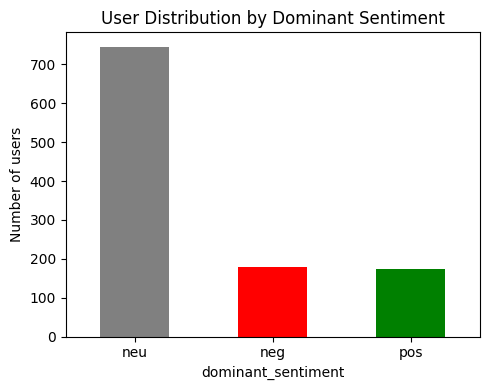

In [ ]:
# NEW USER GROUPING: Dominant Sentiment
# Instead of activity/reach, group users by their dominant tweet sentiment.
# Each user is assigned the sentiment they posted most (Positive/Negative/Neutral).
# If two sentiments are tied, user is labelled "mixed" and excluded from analysis.

# --- Step 1: Show sentiment counts per user ---
# This answers the question: "how many positive/negative/neutral tweets does each user have?"
sentiment_counts_per_user = df1_clean.groupby(
    ["original_author", "sentiment"]).size().unstack(fill_value=0)

# Keep only users with >=10 tweets
sentiment_counts_per_user = sentiment_counts_per_user[
    sentiment_counts_per_user.index.isin(user_profiles["original_author"])
]

print("Sentiment counts per user (sample of 10):")
print(sentiment_counts_per_user.head(10))

print("\nTotal tweets per sentiment across all users:")
print(sentiment_counts_per_user.sum())

print("\nAverage tweets per sentiment per user:")
print(sentiment_counts_per_user.mean().round(2))

# --- Step 2: Assign dominant sentiment per user ---
sentiment_profiles = df1_clean.groupby("original_author")["sentiment"].value_counts()
sentiment_profiles = sentiment_profiles.reset_index()
sentiment_profiles.columns = ["original_author", "sentiment", "count"]

def get_dominant_sentiment(author):
    user_data = sentiment_profiles[
        sentiment_profiles["original_author"] == author
    ].sort_values("count", ascending=False)

    if len(user_data) == 0:
        return "unknown"

    top_count = user_data.iloc[0]["count"]
    top_rows = user_data[user_data["count"] == top_count]

    # Tie handling: if two sentiments are equally dominant → mixed
    if len(top_rows) > 1:
        return "mixed"
    return user_data.iloc[0]["sentiment"]

# Apply to filtered user profiles (>=10 tweets)
user_profiles["dominant_sentiment"] = user_profiles["original_author"].apply(
    get_dominant_sentiment
)

print("\nDominant sentiment distribution:")
print(user_profiles["dominant_sentiment"].value_counts())

# --- Step 3: Exclude mixed/unknown users ---
sentiment_users = user_profiles[
    user_profiles["dominant_sentiment"].isin(["pos", "neg", "neu"])
].copy()

print("\nUsers after excluding mixed/unknown:", len(sentiment_users))
print(sentiment_users["dominant_sentiment"].value_counts())

# --- Step 4: Visualise ---
sentiment_users["dominant_sentiment"].value_counts().plot(
    kind="bar", color=["gray", "red", "green"], figsize=(5, 4)
)
plt.title("User Distribution by Dominant Sentiment")
plt.ylabel("Number of users")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# **Cell 10 — Stratified Sample by Sentiment**

In [ ]:
# Stratified sample: equal number of users per sentiment group
# This ensures fair comparison across Positive/Negative/Neutral users

sent_group_sizes = sentiment_users.groupby("dominant_sentiment").size()
print("Sentiment group sizes:")
print(sent_group_sizes)

N_SENT = min(100, sent_group_sizes.min())

sampled_sentiment = (
    sentiment_users
    .groupby("dominant_sentiment", group_keys=False)
    .sample(n=N_SENT, random_state=42)
    .reset_index(drop=True)
)

print(f"\nSampled {N_SENT} users per group:")
print(sampled_sentiment.groupby("dominant_sentiment").size())

Sentiment group sizes:
dominant_sentiment
neg    179
neu    745
pos    173
dtype: int64

Sampled 100 users per group:
dominant_sentiment
neg    100
neu    100
pos    100
dtype: int64


# **Cell 11 — M3: Doc2Vec (ZhengWei et al., 2022)**

In [ ]:
# METHOD 3: Doc2Vec - Paragraph Vector (PV-DBOW)
# Reference: ZhengWei et al. (2022) - Recommendation Method for Academic
# Journal Submission Based on Doc2Vec and XGBoost
#
# Doc2Vec extends Word2Vec from word level to document level.
# Each tweet is represented as a 300-dimensional vector capturing
# semantic meaning including word order and context.
# User vector = inferred Doc2Vec vector from the user full profile text.
# Parameters follow ZhengWei et al.: vector_size=300, window=5, epochs=20

!pip install gensim -q
from gensim.models.doc2vec import Doc2Vec, TaggedDocument

# Prepare tagged data: each tweet gets its row index as a unique string tag
tagged_data = [
    TaggedDocument(words=text.split(), tags=[str(i)])
    for i, text in enumerate(df2_clean['clean_text'])
]

# Train Doc2Vec (PV-DBOW, dm=0) with ZhengWei et al. (2022) parameters
doc2vec_model = Doc2Vec(
    vector_size=300,   # 300-dimensional document vectors
    window=5,          # context window size
    min_count=2,       # ignore words appearing fewer than 2 times
    workers=4,
    dm=0,              # PV-DBOW mode
    epochs=20,
)
doc2vec_model.build_vocab(tagged_data)
doc2vec_model.train(
    tagged_data,
    total_examples=doc2vec_model.corpus_count,
    epochs=doc2vec_model.epochs
)
print('Doc2Vec model trained.')

# Pre-compute all Data 2 vectors
pool_vectors_d2v = np.array([
    doc2vec_model.dv[str(i)] for i in range(len(df2_clean))
])
print('Doc2Vec pool shape:', pool_vectors_d2v.shape)

def recommend_doc2vec(user_text, pool_df, pool_vectors, model, k=K):
    user_vec = model.infer_vector(user_text.split())
    sims = cosine_similarity([user_vec], pool_vectors).flatten()
    top_idx = np.argsort(sims)[-k:][::-1]
    return pool_df.iloc[top_idx]

results_m3 = []
for i, user in sampled.iterrows():
    recs = recommend_doc2vec(user['profile_text'], df2_clean,
                             pool_vectors_d2v, doc2vec_model, k=K)
    labels = recs['cyberbullying_type']
    exposure_rate = (labels != 'not_cyberbullying').mean()
    type_counts = labels.value_counts().to_dict()
    results_m3.append({
        'author': user['original_author'],
        'activity_group': user['activity_group'],
        'reach_group': user['reach_group'],
        'method': 'M3_Doc2Vec',
        'exposure_rate': exposure_rate,
        **type_counts,
    })

results_m3 = pd.DataFrame(results_m3).fillna(0)
print('M3 done.')
print('Mean exposure rate:', results_m3['exposure_rate'].mean().round(4))
print('\nExposure by user group:')
print(results_m3.groupby(['activity_group','reach_group'])['exposure_rate'].mean().round(4))
results_m3.head()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 78.3 MB/s eta 0:00:00
Doc2Vec model trained.
Doc2Vec pool shape: (47692, 300)
M3 done.
Mean exposure rate: 0.6597

Exposure by user group:
activity_group  reach_group
high            high           0.647
                low            0.653
low             high           0.649
                low            0.690
Name: exposure_rate, dtype: float64


,author,activity_group,reach_group,method,exposure_rate,age,gender,ethnicity,religion,not_cyberbullying,other_cyberbullying
0,anas_erindra,high,high,M3_Doc2Vec,1.0,5.0,2.0,2.0,1.0,0.0,0.0
1,threadreaderapp,high,high,M3_Doc2Vec,0.4,1.0,0.0,1.0,0.0,6.0,2.0
2,jazmasigan_2,high,high,M3_Doc2Vec,0.8,8.0,0.0,0.0,0.0,2.0,0.0
3,dYu7vug97v2Qcqh,high,high,M3_Doc2Vec,0.9,3.0,0.0,0.0,6.0,1.0,0.0
4,GlobalRegina,high,high,M3_Doc2Vec,0.4,3.0,0.0,0.0,1.0,6.0,0.0


# **Cell 12 — M4: Sentence-BERT (Reimers & Gurevych, 2019)**

In [ ]:
# METHOD 4: Sentence-BERT (SBERT)
# Reference: Reimers & Gurevych (2019) - Sentence-BERT: Sentence Embeddings
# using Siamese BERT-Networks (EMNLP 2019)
#
# SBERT modifies BERT using siamese networks to generate semantically
# meaningful sentence embeddings comparable via cosine similarity.
# Unlike TF-IDF (lexical) or Doc2Vec, SBERT captures deep semantic meaning.
# User embedding = MEAN pooling of tweet embeddings.
# Best pooling strategy per Reimers & Gurevych (2019) Table 6: MEAN.
# Model: paraphrase-MiniLM-L6-v2 (also used in Armadianti et al. 2025)

!pip install sentence-transformers -q
from sentence_transformers import SentenceTransformer

sbert_model = SentenceTransformer('paraphrase-MiniLM-L6-v2')
print('SBERT model loaded.')

# Encode all Data 2 tweets once (pre-compute pool embeddings)
print('Encoding Data 2 pool with SBERT (may take a few minutes)...')
pool_vectors_sbert = sbert_model.encode(
    df2_clean['tweet_text'].tolist(),
    batch_size=128,
    show_progress_bar=True,
    convert_to_numpy=True,
)
print('SBERT pool shape:', pool_vectors_sbert.shape)

def recommend_sbert(user_text, pool_df, pool_vectors, model, k=K):
    # Split profile into tweets, encode each, then MEAN pool
    tweets = [t for t in user_text.split('. ') if len(t.strip()) > 5]
    if not tweets:
        tweets = [user_text]
    tweet_vecs = model.encode(tweets, convert_to_numpy=True)
    user_vec = tweet_vecs.mean(axis=0)   # MEAN pooling per Reimers & Gurevych 2019
    sims = cosine_similarity([user_vec], pool_vectors).flatten()
    top_idx = np.argsort(sims)[-k:][::-1]
    return pool_df.iloc[top_idx]

results_m4 = []
for i, user in sampled.iterrows():
    recs = recommend_sbert(user['profile_text'], df2_clean,
                           pool_vectors_sbert, sbert_model, k=K)
    labels = recs['cyberbullying_type']
    exposure_rate = (labels != 'not_cyberbullying').mean()
    type_counts = labels.value_counts().to_dict()
    results_m4.append({
        'author': user['original_author'],
        'activity_group': user['activity_group'],
        'reach_group': user['reach_group'],
        'method': 'M4_SBERT',
        'exposure_rate': exposure_rate,
        **type_counts,
    })

results_m4 = pd.DataFrame(results_m4).fillna(0)
print('M4 done.')
print('Mean exposure rate:', results_m4['exposure_rate'].mean().round(4))
print('\nExposure by user group:')
print(results_m4.groupby(['activity_group','reach_group'])['exposure_rate'].mean().round(4))
results_m4.head()


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.51k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

SBERT model loaded.
Encoding Data 2 pool with SBERT (may take a few minutes)...


Batches:   0%|          | 0/373 [00:00<?, ?it/s]

SBERT pool shape: (47692, 384)
M4 done.
Mean exposure rate: 0.6765

Exposure by user group:
activity_group  reach_group
high            high           0.682
                low            0.683
low             high           0.678
                low            0.663
Name: exposure_rate, dtype: float64


,author,activity_group,reach_group,method,exposure_rate,religion,ethnicity,other_cyberbullying,not_cyberbullying,age,gender
0,anas_erindra,high,high,M4_SBERT,1.0,7.0,2.0,1.0,0.0,0.0,0.0
1,threadreaderapp,high,high,M4_SBERT,0.6,2.0,2.0,2.0,4.0,0.0,0.0
2,jazmasigan_2,high,high,M4_SBERT,0.7,6.0,1.0,0.0,3.0,0.0,0.0
3,dYu7vug97v2Qcqh,high,high,M4_SBERT,0.9,5.0,0.0,3.0,1.0,1.0,0.0
4,GlobalRegina,high,high,M4_SBERT,0.8,0.0,0.0,1.0,2.0,6.0,1.0


# **Cell 13 — Exposure Metrics (All Methods)**

METRIC 1 - Harmful Content Ratio (HCR)
Definition: Average proportion of recommended tweets
that are harmful, across all users and all methods.
  M1_random            0.8395 (83.95%)
  M2_TFIDF             0.7468 (74.67%)
  M3_Doc2Vec           0.6597 (65.97%)
  M4_SBERT             0.6765 (67.65%)

METRIC 2 - Type Exposure Rate (TER)
Definition: How often each cyberbullying category
appears in recommendations, per method.
            gender  religion     age  ethnicity  other_cyberbullying
M1_random   0.1662    0.1662  0.1720     0.1635               0.1715
M2_TFIDF    0.0865    0.1625  0.1438     0.0625               0.2915
M3_Doc2Vec  0.0222    0.0860  0.4955     0.0345               0.0215
M4_SBERT    0.0432    0.2708  0.0518     0.1422               0.1685


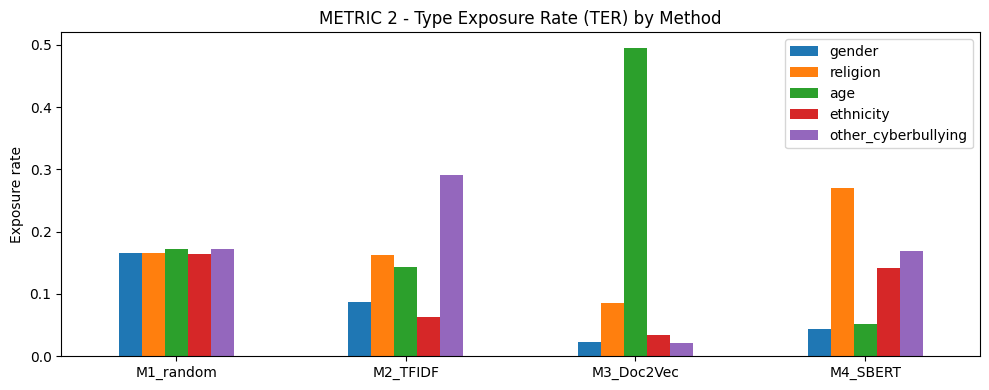


METRIC 3 - Group Exposure Gap (GEG)
Definition: Difference in harmful content exposure
between the most and least exposed user groups.

M1_random:
activity_group  reach_group
high            high           0.830
                low            0.849
low             high           0.842
                low            0.837
Name: exposure_rate, dtype: float64
  Group Exposure Gap: 0.0190 (1.90%)

M2_TFIDF:
activity_group  reach_group
high            high           0.739
                low            0.760
low             high           0.735
                low            0.753
Name: exposure_rate, dtype: float64
  Group Exposure Gap: 0.0250 (2.50%)

M3_Doc2Vec:
activity_group  reach_group
high            high           0.647
                low            0.653
low             high           0.649
                low            0.690
Name: exposure_rate, dtype: float64
  Group Exposure Gap: 0.0430 (4.30%)

M4_SBERT:
activity_group  reach_group
high            high           0.682
     

In [ ]:
# Combine all method results into one DataFrame
results_m2['method'] = 'M2_TFIDF'
results_all = pd.concat(
    [results_m1, results_m2, results_m3, results_m4],
    ignore_index=True
).fillna(0)

type_cols = ['gender', 'religion', 'age', 'ethnicity', 'other_cyberbullying']
method_labels = ['M1_random', 'M2_TFIDF', 'M3_Doc2Vec', 'M4_SBERT']
colors = ['gray', 'steelblue', 'orange', 'green']

# --------------------------------------------------
# METRIC 1: Harmful Content Ratio (HCR)
# Definition: Mean proportion of recommended tweets
# that are harmful, averaged across all users.
# --------------------------------------------------
print('=' * 60)
print('METRIC 1 - Harmful Content Ratio (HCR)')
print('Definition: Average proportion of recommended tweets')
print('that are harmful, across all users and all methods.')
print('=' * 60)

hcr_by_method = results_all.groupby('method')['exposure_rate'].mean()
for method in method_labels:
    rate = hcr_by_method.get(method, 0)
    print(f'  {method:<20} {rate:.4f} ({rate*100:.2f}%)')

# --------------------------------------------------
# METRIC 2: Type Exposure Rate (TER)
# Definition: Proportion of recommended tweets per
# cyberbullying category, for each method.
# --------------------------------------------------
print('\n' + '=' * 60)
print('METRIC 2 - Type Exposure Rate (TER)')
print('Definition: How often each cyberbullying category')
print('appears in recommendations, per method.')
print('=' * 60)

ter_all = {}
for method in method_labels:
    method_df = results_all[results_all['method'] == method]
    ter = {}
    for col in type_cols:
        if col in method_df.columns:
            rate = method_df[col].sum() / (len(method_df) * K)
            ter[col] = round(rate, 4)
    ter_all[method] = ter

ter_df = pd.DataFrame(ter_all).T
print(ter_df)

ter_df.plot(kind='bar', figsize=(10, 4))
plt.title('METRIC 2 - Type Exposure Rate (TER) by Method')
plt.ylabel('Exposure rate')
plt.xticks(rotation=0)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

# --------------------------------------------------
# METRIC 3: Group Exposure Gap (GEG)
# Definition: Difference in exposure between the most
# and least exposed user group, per method.
# --------------------------------------------------
print('\n' + '=' * 60)
print('METRIC 3 - Group Exposure Gap (GEG)')
print('Definition: Difference in harmful content exposure')
print('between the most and least exposed user groups.')
print('=' * 60)

for method in method_labels:
    method_df = results_all[results_all['method'] == method]
    group_exp = method_df.groupby(
        ['activity_group','reach_group'])['exposure_rate'].mean()
    geg = group_exp.max() - group_exp.min()
    print(f'\n{method}:')
    print(group_exp.round(4))
    print(f'  Group Exposure Gap: {geg:.4f} ({geg*100:.2f}%)')


# **Cell 14 — Compare Methods (RQ1, RQ2, RQ3)**

RQ1 - Exposure Rate Comparison (vs M1 baseline)
  M1_random            83.95%  (baseline)
  M2_TFIDF             74.67%  (diff: -9.28%)
  M3_Doc2Vec           65.97%  (diff: -17.98%)
  M4_SBERT             67.65%  (diff: -16.30%)


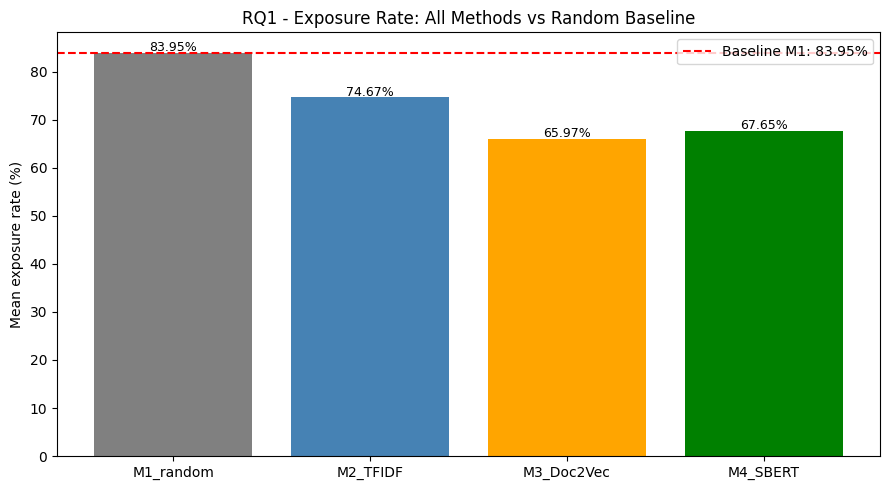


RQ2 - Which cyberbullying type appears most often?


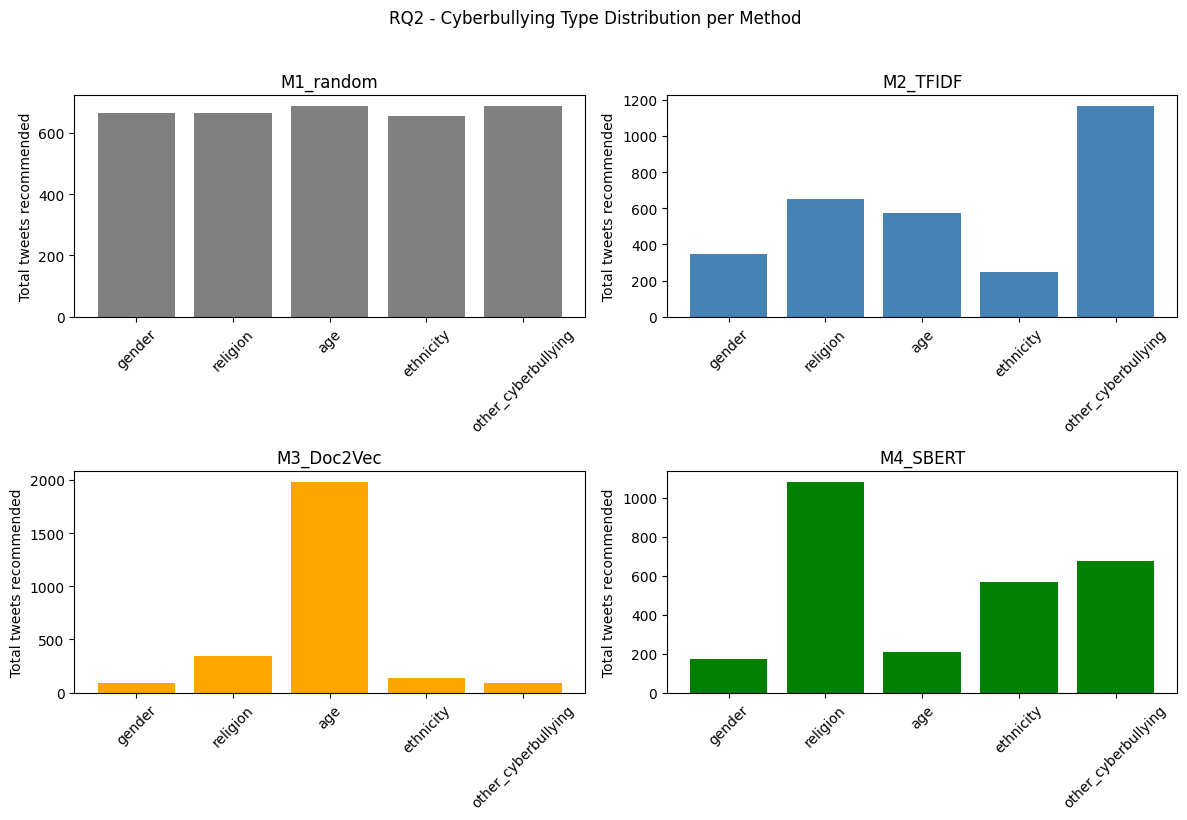

Most frequent type per method:
  M1_random: age (688 tweets)
  M2_TFIDF: other_cyberbullying (1166 tweets)
  M3_Doc2Vec: age (1982 tweets)
  M4_SBERT: religion (1083 tweets)

RQ3 - Which user group is most exposed?


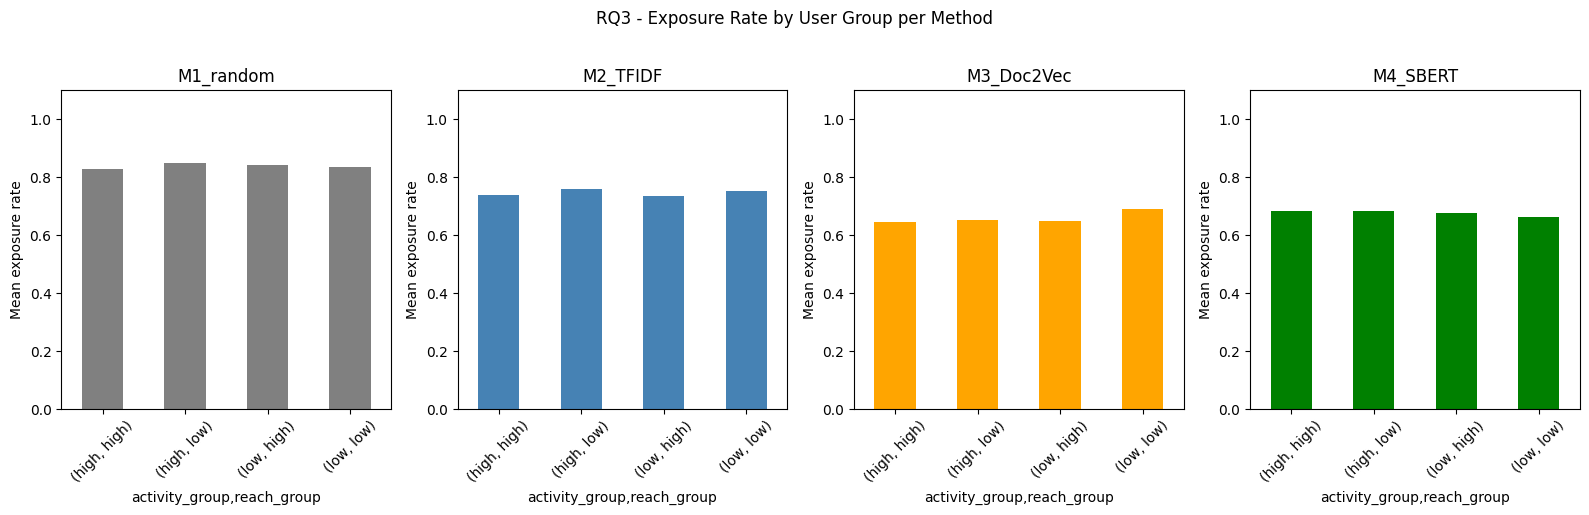

Most/least exposed groups:
  M1_random: most=('high', 'low') (84.9%), gap=1.9%
  M2_TFIDF: most=('high', 'low') (76.0%), gap=2.5%
  M3_Doc2Vec: most=('low', 'low') (69.0%), gap=4.3%
  M4_SBERT: most=('high', 'low') (68.3%), gap=2.0%


In [ ]:
# --------------------------------------------------
# RQ1: Do recommendation methods increase exposure
# compared to the random baseline (M1)?
# --------------------------------------------------
m1_rate = hcr_by_method.get('M1_random', 0)

print('=' * 60)
print('RQ1 - Exposure Rate Comparison (vs M1 baseline)')
print('=' * 60)
for method in method_labels:
    rate = hcr_by_method.get(method, 0)
    diff = rate - m1_rate
    tag = '(baseline)' if method == 'M1_random' else f'(diff: {diff*100:+.2f}%)'
    print(f'  {method:<20} {rate*100:.2f}%  {tag}')

plt.figure(figsize=(9, 5))
bars = plt.bar(
    method_labels,
    [hcr_by_method.get(m, 0)*100 for m in method_labels],
    color=colors
)
plt.axhline(m1_rate*100, color='red', linestyle='--',
            label=f'Baseline M1: {m1_rate*100:.2f}%')
plt.title('RQ1 - Exposure Rate: All Methods vs Random Baseline')
plt.ylabel('Mean exposure rate (%)')
plt.legend()
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{bar.get_height():.2f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# RQ2: Which cyberbullying type appears most?
# --------------------------------------------------
print('\n' + '=' * 60)
print('RQ2 - Which cyberbullying type appears most often?')
print('=' * 60)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for ax, method, color in zip(axes, method_labels, colors):
    method_df = results_all[results_all['method'] == method]
    type_totals = {col: method_df[col].sum()
                   for col in type_cols if col in method_df.columns}
    ax.bar(type_totals.keys(), type_totals.values(), color=color)
    ax.set_title(method)
    ax.set_ylabel('Total tweets recommended')
    ax.tick_params(axis='x', rotation=45)
plt.suptitle('RQ2 - Cyberbullying Type Distribution per Method', y=1.02)
plt.tight_layout()
plt.show()

print('Most frequent type per method:')
for method in method_labels:
    method_df = results_all[results_all['method'] == method]
    type_totals = {col: method_df[col].sum()
                   for col in type_cols if col in method_df.columns}
    if type_totals:
        top = max(type_totals, key=type_totals.get)
        print(f'  {method}: {top} ({type_totals[top]:.0f} tweets)')

# --------------------------------------------------
# RQ3: Which user group is most exposed?
# --------------------------------------------------
print('\n' + '=' * 60)
print('RQ3 - Which user group is most exposed?')
print('=' * 60)

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for ax, method, color in zip(axes, method_labels, colors):
    method_df = results_all[results_all['method'] == method]
    group_exp = method_df.groupby(
        ['activity_group','reach_group'])['exposure_rate'].mean()
    group_exp.plot(kind='bar', ax=ax, color=color)
    ax.set_title(method)
    ax.set_ylabel('Mean exposure rate')
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylim(0, 1.1)
plt.suptitle('RQ3 - Exposure Rate by User Group per Method', y=1.02)
plt.tight_layout()
plt.show()

print('Most/least exposed groups:')
for method in method_labels:
    method_df = results_all[results_all['method'] == method]
    group_exp = method_df.groupby(
        ['activity_group','reach_group'])['exposure_rate'].mean()
    geg = (group_exp.max() - group_exp.min()) * 100
    print(f'  {method}: most={group_exp.idxmax()} '
          f'({group_exp.max()*100:.1f}%), gap={geg:.1f}%')


# **Cell 15 — Final Summary Table**

FINAL SUMMARY - Exposure Metrics Across All Methods
Method                  HCR (%)               Top Type    GEG (%)
----------------------------------------------------------------------
M1_random                 83.95                    age       1.90
M2_TFIDF                  74.67    other_cyberbullying       2.50
M3_Doc2Vec                65.97                    age       4.30
M4_SBERT                  67.65               religion       2.00
----------------------------------------------------------------------

References:
M1 - Baseline: no recommendation algorithm
M2 - Albayati & Ortakci (2022): TF-IDF + Cosine Similarity
M3 - ZhengWei et al. (2022): Doc2Vec (PV-DBOW, vector_size=300)
     Recommendation Method for Academic Journal Submission
M4 - Reimers & Gurevych (2019): Sentence-BERT, EMNLP 2019
     Sentence Embeddings using Siamese BERT-Networks


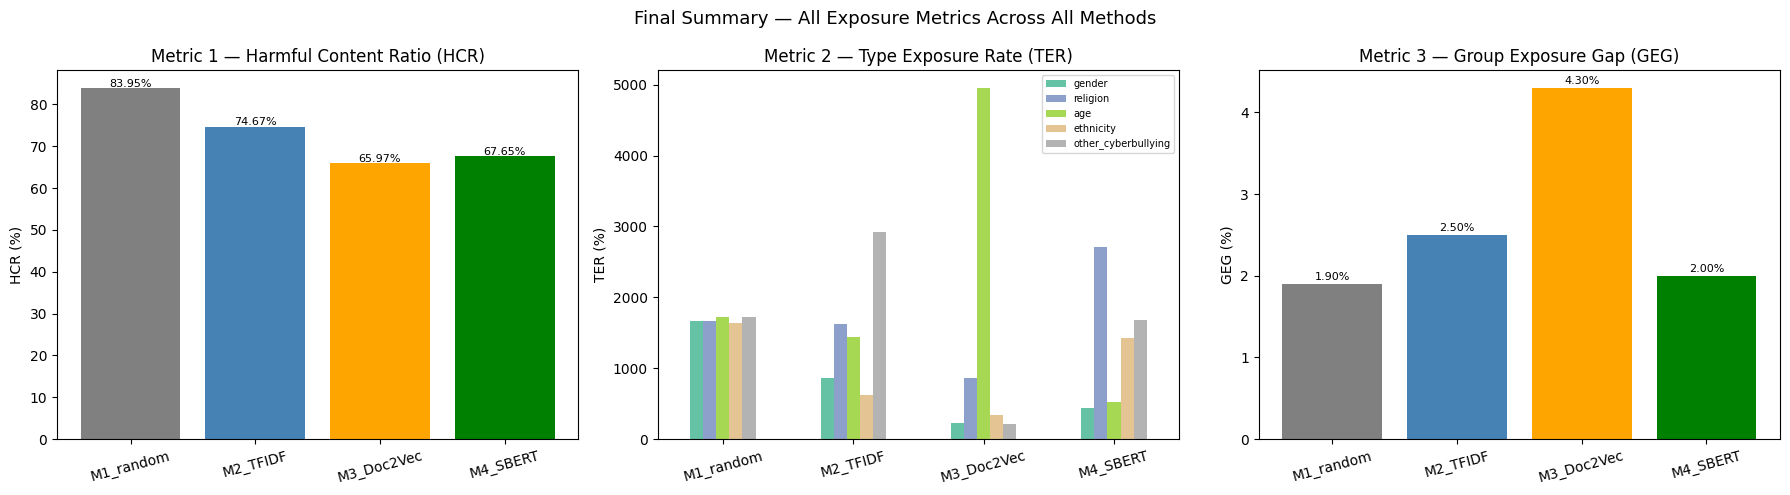

In [ ]:
# Final summary of all exposure metrics across all four methods
print('=' * 70)
print('FINAL SUMMARY - Exposure Metrics Across All Methods')
print('=' * 70)
print(f"{'Method':<20} {'HCR (%)':>10} {'Top Type':>22} {'GEG (%)':>10}")
print('-' * 70)
for method in method_labels:
    method_df = results_all[results_all['method'] == method]
    hcr = method_df['exposure_rate'].mean() * 100
    ter = {col: method_df[col].sum()
           for col in type_cols if col in method_df.columns}
    top_type = max(ter, key=ter.get) if ter else 'N/A'
    group_exp = method_df.groupby(
        ['activity_group','reach_group'])['exposure_rate'].mean()
    geg = (group_exp.max() - group_exp.min()) * 100
    print(f'{method:<20} {hcr:>10.2f} {top_type:>22} {geg:>10.2f}')
print('-' * 70)
print('\nReferences:')
print('M1 - Baseline: no recommendation algorithm')
print('M2 - Albayati & Ortakci (2022): TF-IDF + Cosine Similarity')
print('M3 - ZhengWei et al. (2022): Doc2Vec (PV-DBOW, vector_size=300)')
print('     Recommendation Method for Academic Journal Submission')
print('M4 - Reimers & Gurevych (2019): Sentence-BERT, EMNLP 2019')
print('     Sentence Embeddings using Siamese BERT-Networks')

# ── Visualisation ──────────────────────────────────────────
summary_hcr = []
summary_geg = []
summary_ter = {}

for method in method_labels:
    method_df = results_all[results_all['method'] == method]

    hcr = method_df['exposure_rate'].mean() * 100
    summary_hcr.append(round(hcr, 2))

    group_exp = method_df.groupby(
        ['activity_group','reach_group'])['exposure_rate'].mean()
    geg = (group_exp.max() - group_exp.min()) * 100
    summary_geg.append(round(geg, 2))

    for col in type_cols:
        if col not in summary_ter:
            summary_ter[col] = []
        if col in method_df.columns:
            rate = method_df[col].sum() / (len(method_df) * K) * 100
            summary_ter[col].append(round(rate, 2))
        else:
            summary_ter[col].append(0)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: HCR
bars = axes[0].bar(method_labels, summary_hcr, color=colors)
axes[0].set_title('Metric 1 — Harmful Content Ratio (HCR)')
axes[0].set_ylabel('HCR (%)')
axes[0].tick_params(axis='x', rotation=15)
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f'{bar.get_height():.2f}%',
                 ha='center', fontsize=8)

# Panel 2: TER
ter_df = pd.DataFrame(summary_ter, index=method_labels)
ter_df_pct = ter_df * 100
ter_df_pct.plot(kind='bar', ax=axes[1], colormap='Set2')
axes[1].set_title('Metric 2 — Type Exposure Rate (TER)')
axes[1].set_ylabel('TER (%)')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend(loc='upper right', fontsize=7)

# Panel 3: GEG
bars = axes[2].bar(method_labels, summary_geg, color=colors)
axes[2].set_title('Metric 3 — Group Exposure Gap (GEG)')
axes[2].set_ylabel('GEG (%)')
axes[2].tick_params(axis='x', rotation=15)
for bar in bars:
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.05,
                 f'{bar.get_height():.2f}%',
                 ha='center', fontsize=8)

plt.suptitle('Final Summary — All Exposure Metrics Across All Methods',
             fontsize=13)
plt.tight_layout()
plt.show()

# **Cell 16 — Run All Methods on Sentiment Groups**

In [ ]:
# Run all 4 methods on sentiment-grouped users
# Same methods, new grouping → answers "which sentiment group is most exposed?"

sent_results_all = []

for i, user in sampled_sentiment.iterrows():

    # M1: Random
    recs = recommend_random(df2_clean, k=K, seed=i)
    labels = recs["cyberbullying_type"]
    sent_results_all.append({
        "author": user["original_author"],
        "dominant_sentiment": user["dominant_sentiment"],
        "method": "M1_random",
        "exposure_rate": (labels != "not_cyberbullying").mean(),
        **labels.value_counts().to_dict(),
    })

    # M2: TF-IDF
    recs = recommend_content_based(user["profile_text"], df2_clean, tfidf_pool, tfidf, k=K)
    labels = recs["cyberbullying_type"]
    sent_results_all.append({
        "author": user["original_author"],
        "dominant_sentiment": user["dominant_sentiment"],
        "method": "M2_TFIDF",
        "exposure_rate": (labels != "not_cyberbullying").mean(),
        **labels.value_counts().to_dict(),
    })

    # M3: Doc2Vec
    recs = recommend_doc2vec(user["profile_text"], df2_clean,
                              pool_vectors_d2v, doc2vec_model, k=K)
    labels = recs["cyberbullying_type"]
    sent_results_all.append({
        "author": user["original_author"],
        "dominant_sentiment": user["dominant_sentiment"],
        "method": "M3_Doc2Vec",
        "exposure_rate": (labels != "not_cyberbullying").mean(),
        **labels.value_counts().to_dict(),
    })

    # M4: SBERT
    recs = recommend_sbert(user["profile_text"], df2_clean,
                            pool_vectors_sbert, sbert_model, k=K)
    labels = recs["cyberbullying_type"]
    sent_results_all.append({
        "author": user["original_author"],
        "dominant_sentiment": user["dominant_sentiment"],
        "method": "M4_SBERT",
        "exposure_rate": (labels != "not_cyberbullying").mean(),
        **labels.value_counts().to_dict(),
    })

sent_results_df = pd.DataFrame(sent_results_all).fillna(0)
print("Done. Shape:", sent_results_df.shape)
sent_results_df.head()

Done. Shape: (1200, 10)


,author,dominant_sentiment,method,exposure_rate,other_cyberbullying,religion,age,gender,not_cyberbullying,ethnicity
0,TheCounter,neg,M1_random,0.9,3.0,2.0,2.0,1.0,1.0,1.0
1,TheCounter,neg,M2_TFIDF,0.7,4.0,1.0,0.0,1.0,3.0,1.0
2,TheCounter,neg,M3_Doc2Vec,0.9,0.0,0.0,9.0,0.0,1.0,0.0
3,TheCounter,neg,M4_SBERT,0.2,2.0,0.0,0.0,0.0,8.0,0.0
4,COVID19_bot,neg,M1_random,1.0,0.0,2.0,2.0,2.0,0.0,4.0


# **Cell 17 — Sentiment Group Exposure Results**

SENTIMENT GROUP ANALYSIS — Exposure Rate by Dominant Sentiment
dominant_sentiment    neg    neu    pos
method                                 
M1_random           0.830  0.849  0.842
M2_TFIDF            0.754  0.748  0.720
M3_Doc2Vec          0.671  0.654  0.722
M4_SBERT            0.741  0.682  0.663


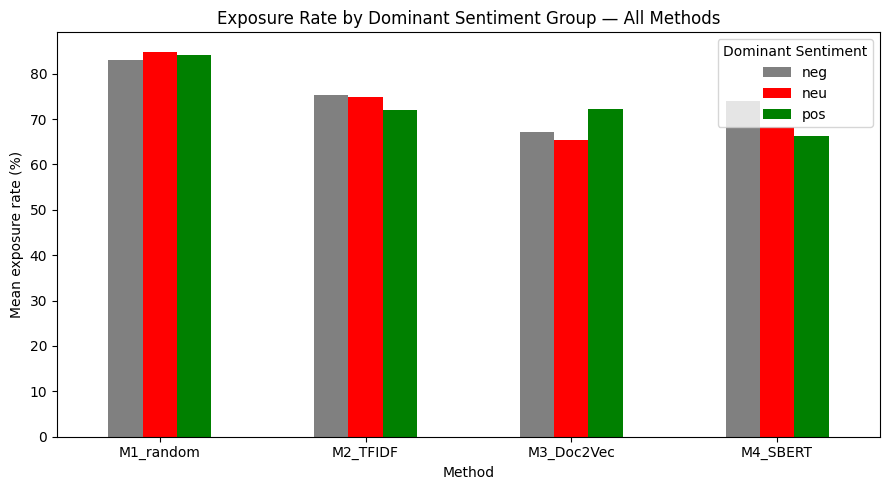


Conclusion:
  M1_random: most exposed = neu (84.90%), least = neg (83.00%)
  M2_TFIDF: most exposed = neg (75.40%), least = pos (72.00%)
  M3_Doc2Vec: most exposed = pos (72.20%), least = neu (65.40%)
  M4_SBERT: most exposed = neg (74.10%), least = pos (66.30%)
GROUP EXPOSURE GAP (GEG) — Sentiment Groups

M1_random:
  Most exposed:  neu (84.90%)
  Least exposed: neg (83.00%)
  GEG = 1.90%

M2_TFIDF:
  Most exposed:  neg (75.40%)
  Least exposed: pos (72.00%)
  GEG = 3.40%

M3_Doc2Vec:
  Most exposed:  pos (72.20%)
  Least exposed: neu (65.40%)
  GEG = 6.80%

M4_SBERT:
  Most exposed:  neg (74.10%)
  Least exposed: pos (66.30%)
  GEG = 7.80%


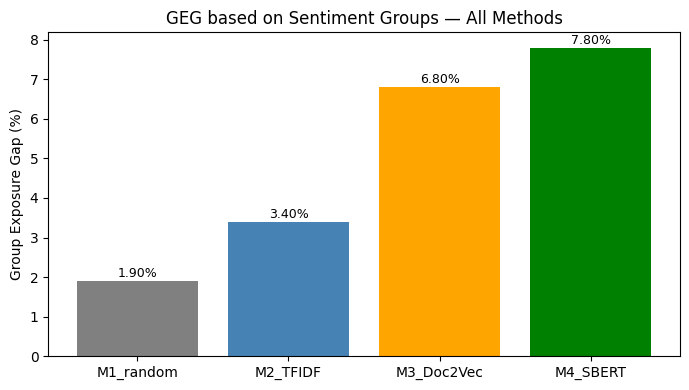


SUMMARY — GEG by Sentiment Groups
Method             Most Exposed   Least Exposed    GEG (%)
-----------------------------------------------------------------
M1_random                   neu             neg       1.90
M2_TFIDF                    neg             pos       3.40
M3_Doc2Vec                  pos             neu       6.80
M4_SBERT                    neg             pos       7.80
-----------------------------------------------------------------


In [ ]:
# Compare exposure rates across Positive/Negative/Neutral user groups
# for each recommendation method

print("=" * 65)
print("SENTIMENT GROUP ANALYSIS — Exposure Rate by Dominant Sentiment")
print("=" * 65)

sent_pivot = sent_results_df.groupby(
    ["method", "dominant_sentiment"])["exposure_rate"].mean().unstack()
print(sent_pivot.round(4))

# Visualise
sent_pivot_pct = sent_pivot * 100
sent_pivot_pct.plot(kind="bar", figsize=(9, 5),
                    color=["gray", "red", "green"])
plt.title("Exposure Rate by Dominant Sentiment Group — All Methods")
plt.ylabel("Mean exposure rate (%)")
plt.xlabel("Method")
plt.xticks(rotation=0)
plt.legend(title="Dominant Sentiment")
plt.tight_layout()
plt.show()

# Answer RQ3 for sentiment grouping
print("\nConclusion:")
for method in method_labels:
    method_df = sent_results_df[sent_results_df["method"] == method]
    group_exp = method_df.groupby("dominant_sentiment")["exposure_rate"].mean()
    most = group_exp.idxmax()
    least = group_exp.idxmin()
    print(f"  {method}: most exposed = {most} ({group_exp[most]*100:.2f}%), "
          f"least = {least} ({group_exp[least]*100:.2f}%)")

# GEG based on Sentiment Groups (separate from Activity/Reach GEG)

print("=" * 65)
print("GROUP EXPOSURE GAP (GEG) — Sentiment Groups")
print("=" * 65)

sent_geg_results = []

for method in method_labels:
    method_df = sent_results_df[sent_results_df["method"] == method]
    group_exp = method_df.groupby("dominant_sentiment")["exposure_rate"].mean()

    geg = (group_exp.max() - group_exp.min()) * 100
    most = group_exp.idxmax()
    least = group_exp.idxmin()

    sent_geg_results.append({
        "method": method,
        "most_exposed_group": most,
        "most_exposed_rate": round(group_exp[most] * 100, 2),
        "least_exposed_group": least,
        "least_exposed_rate": round(group_exp[least] * 100, 2),
        "GEG (%)": round(geg, 2),
    })

    print(f"\n{method}:")
    print(f"  Most exposed:  {most} ({group_exp[most]*100:.2f}%)")
    print(f"  Least exposed: {least} ({group_exp[least]*100:.2f}%)")
    print(f"  GEG = {geg:.2f}%")

# GEG bar chart for sentiment groups
geg_df = pd.DataFrame(sent_geg_results).set_index("method")

plt.figure(figsize=(7, 4))
bars = plt.bar(geg_df.index, geg_df["GEG (%)"], color=colors)
plt.title("GEG based on Sentiment Groups — All Methods")
plt.ylabel("Group Exposure Gap (%)")
plt.xticks(rotation=0)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.1,
             f'{bar.get_height():.2f}%',
             ha='center', fontsize=9)
plt.tight_layout()
plt.show()

# Summary table
print("\n" + "=" * 65)
print("SUMMARY — GEG by Sentiment Groups")
print("=" * 65)
print(f"{'Method':<15} {'Most Exposed':>15} {'Least Exposed':>15} {'GEG (%)':>10}")
print("-" * 65)
for _, row in geg_df.iterrows():
    print(f"{row.name:<15} "
          f"{row['most_exposed_group']:>15} "
          f"{row['least_exposed_group']:>15} "
          f"{row['GEG (%)']:>10.2f}")
print("-" * 65)